In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.spatial.distance import pdist, squareform

from sklearn.manifold import MDS

In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()

if BASE_DIR.name == "Notebooks":
    BASE_DIR = BASE_DIR.parent

DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"
DOC_DIR = BASE_DIR / "Docs"

In [4]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [5]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [6]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [7]:
# liste des oeuvres

the_works = matrix_all_extended["Works"].unique().tolist()

In [8]:
# liste des thèmes

the_themes = matrix_themes.columns.values.tolist()

**Distance de Jaccard entre les oeuvres**

In [9]:
# la distance de Jaccard est calculée entre toutes les paires de lignes :
# 173 oeuvres => [173 x (173-1)]/2 paires (=14878)

MW = matrix_themes.to_numpy().astype(bool)

dist_jaccard_W = pdist(
    MW, 
    metric="jaccard"
)

**Recherche de n_init pour MDS**

In [10]:
import time

D = squareform(dist_jaccard_W)

resultats = []

for n in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]:
    debut = time.perf_counter()

    mds = MDS(
        n_components=2,
        metric="precomputed",
        random_state=0,
        n_init=n,
        init="random",
        n_jobs=-1
    )

    coords = mds.fit_transform(D)

    fin = time.perf_counter()

    resultats.append({
        "n_init": n,
        "stress": round(mds.stress_,3),
        "temps_secondes": fin - debut
    })

df_stress = pd.DataFrame(resultats)
df_stress

,n_init,stress,temps_secondes
0,1,2017.629,2.077201
1,2,1956.292,1.799345
2,4,1956.292,2.003319
3,8,1956.292,1.853615
4,16,1955.202,0.777751
5,32,1955.202,1.605609
6,64,1942.837,3.736058
7,128,1942.837,7.160300
8,256,1942.837,13.510336
9,512,1931.670,26.231014


**Projection MDS en 2D**

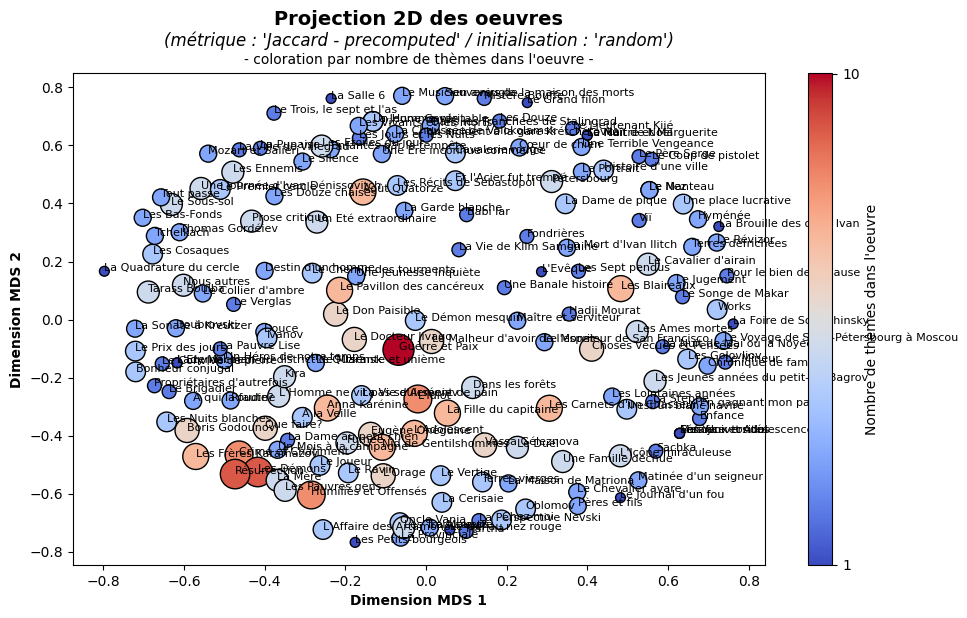

In [11]:
mds = MDS(
    n_components=2,
    metric="precomputed",
    random_state=0,
    n_init=64,  # choix déterminé par tableau de recherche, stress plus faible, temps encore raisonnable
    init="random"
)

coords = mds.fit_transform(squareform(dist_jaccard_W))

# oeuvres en ligne => nombre de thèmes apparaissant dans une oeuvre
work_freq = matrix_themes.sum(axis=1)
vmin = work_freq.min()
vmax = work_freq.max()

fig, ax = plt.subplots(figsize=(10, 6))

# stocker l'objet scatter
sc = ax.scatter(
    coords[:,0],
    coords[:,1],
    c=work_freq,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    s = work_freq * 50,
    edgecolor="black",
    alpha=1.0
)

for i, txt in enumerate(the_works):
    ax.annotate(
        txt,
        (coords[i,0], coords[i,1]),
        fontsize=8,
        alpha=1.0
    )

# ajouter une barre de couleurs
cbar = plt.colorbar(sc)
cbar.set_label("Nombre de thèmes dans l'oeuvre")
ticks = [vmin,vmax]
cbar.set_ticks(ticks)

ax.set_xlabel("Dimension MDS 1", fontweight="bold")
ax.set_ylabel("Dimension MDS 2", fontweight="bold")

fig.tight_layout(rect=[0, 0, 1, 0.95])

titres(
    fig,
    ax,
    t1="Projection 2D des oeuvres", y1=35,
    t2="(métrique : 'Jaccard - precomputed' / initialisation : 'random')", y2=20,
    t3="- coloration par nombre de thèmes dans l'oeuvre -", y3=7
)

fig.savefig(
    IMG_DIR / "oeuvres_projection_2D_par_MDS.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Afficher les labels que pour les œuvres ayant au moins 5 thèmes**

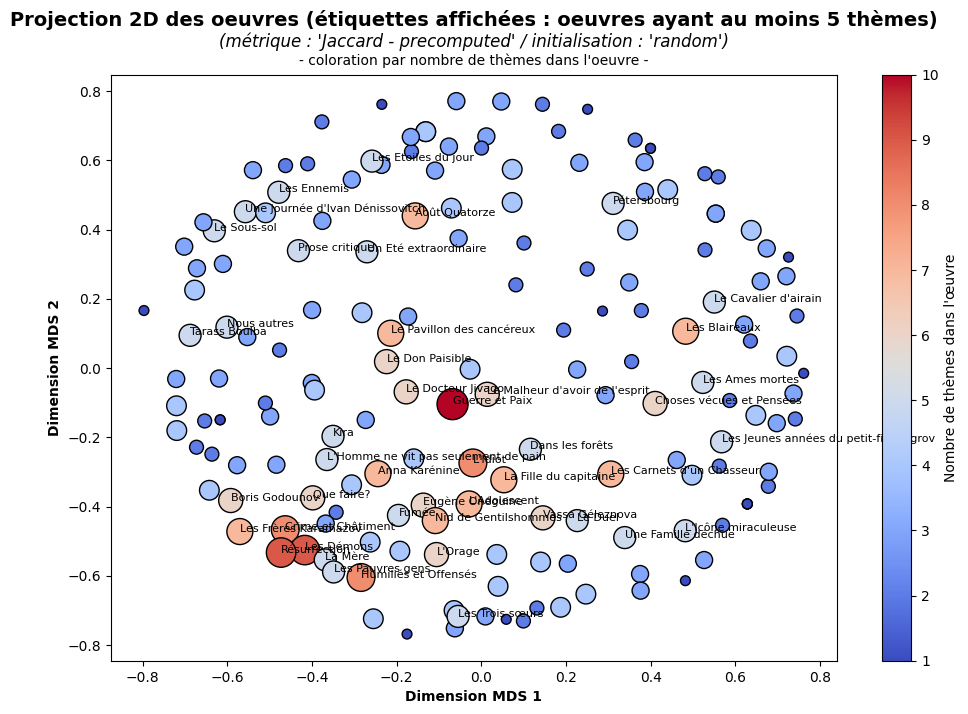

In [12]:
mds = MDS(
    n_components=2,
    metric="precomputed",
    random_state=0,
    n_init=64,
    init="random"
)

coords = mds.fit_transform(squareform(dist_jaccard_W))

# oeuvres en ligne => nombre de thèmes apparaissant dans une oeuvre
work_freq = matrix_themes.sum(axis=1)
vmin = work_freq.min()
vmax = work_freq.max()

work_freq = matrix_themes.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    coords[:,0],
    coords[:,1],
    c=work_freq,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    s = work_freq * 50,
    edgecolor="black",
    alpha=1
)

# On n'affiche les labels que pour les œuvres ayant au moins 5 thèmes
min_themes_label = 5

for i, txt in enumerate(the_works):
    
    if work_freq.iloc[i] >= min_themes_label:
        
        ax.annotate(
            txt,
            (coords[i, 0], coords[i, 1]),
            fontsize=8,
            rotation=0,
#            fontweight="bold",
            alpha=1.0
        )

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Nombre de thèmes dans l'œuvre")

ax.set_xlabel("Dimension MDS 1", fontweight="bold")
ax.set_ylabel("Dimension MDS 2", fontweight="bold")


plt.tight_layout(rect=[0, 0, 1, 0.95])

titres(
    fig,
    ax,
    t1="Projection 2D des oeuvres (étiquettes affichées : oeuvres ayant au moins 5 thèmes)", y1=35,
    t2="(métrique : 'Jaccard - precomputed' / initialisation : 'random')", y2=20,
    t3="- coloration par nombre de thèmes dans l'oeuvre -", y3=7
)

fig.savefig(
    IMG_DIR / "oeuvres_projection_2D_par_MDS_restreint.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
